In [34]:
#A2.1.2.
import pandas as pd
import os
from sklearn.model_selection import train_test_split

gl_data = pd.read_excel(os.path.join(os.getcwd(), "DigiJazz_transactions.xlsx"), sheet_name="GLData");
gl_data

,Date,Period,Description,JournalCode,JournalDesc,JournalType,Booknr,AccountCode,AccountDesc,AccountType,Debit/Credit,Amount,Product ID,User,Relation_id,Relation_name,Source_id,Account
0,2024-04-26,2024-04,Digijazz.nl Order - Mp3603,SJ,Sales Journal,Sales,SJ079206,8000,Revenue digital music,Revenue,Credit,9.00,1000.0,MagentoImporter,CUST000259,Kim van der Meer,MAG#446945,8000 Revenue digital music
1,2024-10-09,2024-10,iDEAL Payment Received for #SJ077467,CJ,Cash Journal,Cash,CJ080560,1101,Bank account *313,Asset,Debit,28.98,NaN,MagentoImporter,NaN,NaN,MAG#445206,1101 Bank account *313
2,2024-12-28,2024-12,Digijazz.nl Order - Mp3556,SJ,Sales Journal,Sales,SJ053087,1300,Debtors,Asset,Debit,24.08,NaN,MagentoImporter,CUST000228,Aisha Aït El Hadi,MAG#420826,1300 Debtors
3,2024-03-24,2024-03,Digijazz.nl Order - Vinyl,CO,Automated Article Journal,Purchases,CO035443,1200,Inventory Vinyl,Asset,Credit,31.74,2000.0,MagentoImporter,CUST000218,Willem van der Linden,MAG#403182,1200 Inventory Vinyl
4,2024-08-12,2024-08,iDEAL Payment Received for #SJ092001,CJ,Cash Journal,Cash,CJ095094,1101,Bank account *313,Asset,Debit,90.14,NaN,MagentoImporter,NaN,NaN,MAG#459740,1101 Bank account *313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646773,2024-05-07,2024-05,iDEAL Payment Received for #SJ010454,CJ,Cash Journal,Cash,CJ013547,1101,Bank account *313,Asset,Debit,7.14,NaN,MagentoImporter,NaN,NaN,MAG#378193,1101 Bank account *313
646774,2024-06-25,2024-06,Digijazz.nl Order - Vinyl,CO,Automated Article Journal,Purchases,CO093559,1200,Inventory Vinyl,Asset,Credit,37.61,2000.0,MagentoImporter,CUST000250,Nadine de Boer,MAG#461298,1200 Inventory Vinyl
646775,2024-06-20,2024-06,Digijazz.nl Order - Vinyl,SJ,Sales Journal,Sales,SJ020971,1500,VAT Payable,Liability,Credit,15.52,NaN,MagentoImporter,NaN,NaN,MAG#388710,1500 VAT Payable
646776,2024-04-23,2024-04,Digijazz.nl Order - Vinyl,CO,Automated Article Journal,Purchases,CO062987,7001,Cost of sales Vinyl,COGS,Debit,45.93,NaN,MagentoImporter,CUST000019,Charlotte Verhoeven,MAG#430726,7001 Cost of sales Vinyl


In [44]:
set(gl_data.Period)


{'2024-01',
 '2024-02',
 '2024-03',
 '2024-04',
 '2024-05',
 '2024-06',
 '2024-07',
 '2024-08',
 '2024-09',
 '2024-10',
 '2024-11',
 '2024-12'}

In [46]:
# Set AmountNet to 1x the Amount for Debit transactions
gl_data.loc[gl_data['Debit/Credit'] == 'Debit', 'AmountNet'] = gl_data['Amount']
# Set AmountNet to 1x the Amount for Credit transactions
gl_data.loc[gl_data['Debit/Credit'] != 'Debit', 'AmountNet'] = gl_data['Amount'] * -1

# Group to GL totals per period basedon the Date column
gl_data['YearWeek'] = gl_data['Date'].dt.strftime('%Y-%U')

glg = gl_data.pivot_table(index=['YearWeek'], columns='Account', values='AmountNet', aggfunc='sum').reset_index()
glg = glg.fillna(0)
glg

Account,YearWeek,1101 Bank account *313,1200 Inventory Vinyl,1300 Debtors,1500 VAT Payable,1520 VAT Recoverable,1600 Creditors,1670 Net wages,1780 Payable reservation for vacation allowance,1910 Accruals Payable,...,5510 Purchases,5511 Rent Expense,5512 Accounting and Audit Fees,5513 Utilities,5514 Car Lease,5520 IT Hosting,7000 Cost of sales digital music,7001 Cost of sales Vinyl,8000 Revenue digital music,8001 Revenue Vinyl
0,2024-00,8927.58,-28961.27,24541.08,-11761.42,5503.02,2598.80,-22236.00,-2400.0,0.00,...,26204.89,0.0,0.00,0.0,0.0,0.00,7456.35,28961.27,-11405.74,-44608.21
1,2024-01,33089.83,-32860.32,-3233.55,-13461.97,4763.04,-17993.71,22236.00,0.0,-7946.67,...,22681.17,1200.0,6666.67,600.0,5200.0,1312.36,9103.53,32860.32,-14036.27,-50076.90
2,2024-02,36778.52,-35778.08,2552.35,-14509.14,3372.75,24844.98,0.00,0.0,0.00,...,16060.73,0.0,0.00,0.0,0.0,0.00,9263.21,35778.08,-14263.42,-54836.77
3,2024-03,68424.66,-33592.96,-2003.74,-13598.28,4475.75,-13849.51,0.00,0.0,0.00,...,21313.10,0.0,0.00,0.0,0.0,0.00,8790.96,33592.96,-13497.32,-51264.66
4,2024-04,37395.64,-33108.47,1431.63,-13537.18,5865.72,5383.33,-22000.73,-2400.0,0.00,...,27932.00,0.0,0.00,0.0,0.0,0.00,8896.01,33108.47,-13562.71,-50908.43
5,2024-05,10568.10,-36859.84,111.46,-14647.93,4357.04,10281.12,22000.73,0.0,-7946.67,...,20747.85,1200.0,6666.67,600.0,5200.0,1622.38,8689.94,36859.84,-13421.72,-56339.03
6,2024-06,63739.27,-32553.63,406.39,-13408.57,6509.19,-24384.16,0.00,0.0,0.00,...,30996.09,0.0,0.00,0.0,0.0,0.00,8910.63,32553.63,-13615.37,-50242.84
7,2024-07,31457.57,-34308.69,-523.82,-13951.07,2791.86,33372.75,0.00,0.0,0.00,...,13294.57,0.0,0.00,0.0,0.0,0.00,8896.02,34308.69,-13682.01,-52759.85
8,2024-08,70097.51,-32617.91,-2366.07,-13449.51,3214.63,-8750.17,-21971.30,-2400.0,0.00,...,15307.77,0.0,0.00,0.0,0.0,0.00,8948.52,32617.91,-13820.29,-50233.87
9,2024-09,25805.09,-35219.75,2233.97,-14408.02,3759.62,-8626.52,21971.30,0.0,-4106.67,...,17902.89,1200.0,6666.67,600.0,5200.0,1420.43,9223.41,35219.75,-14180.66,-54438.10


In [51]:
glg['Revenue'] = -glg['8000 Revenue digital music'] - glg['8001 Revenue Vinyl']

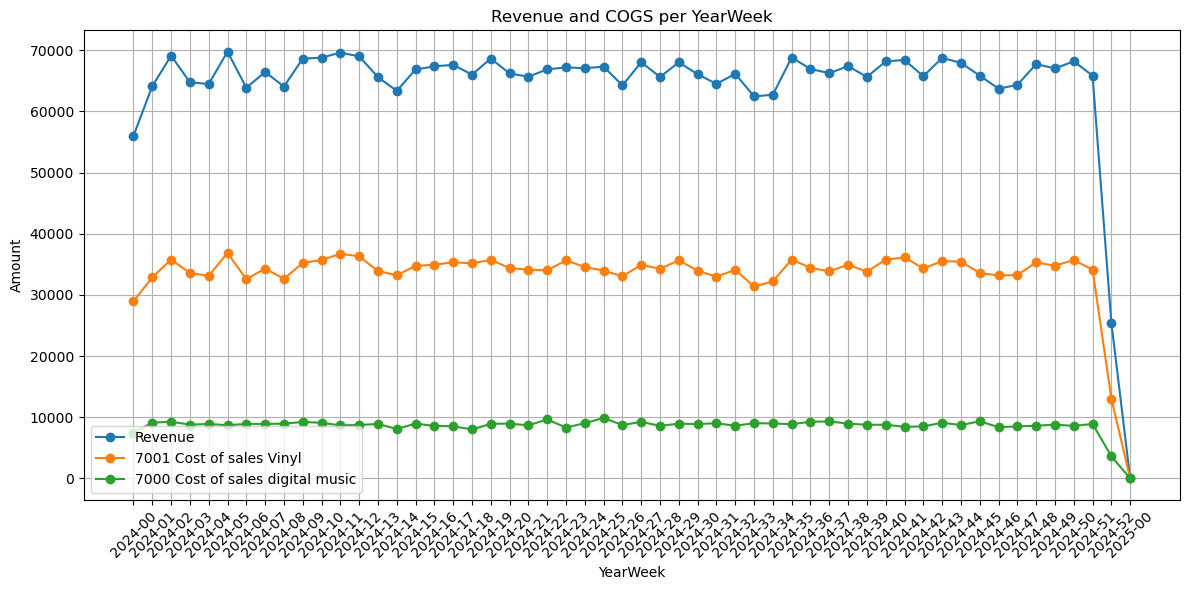

In [52]:
# Plot revenue and the COGS accounts per YearWeek
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(glg['YearWeek'], glg['Revenue'], label='Revenue', marker='o')
plt.plot(glg['YearWeek'], glg['7001 Cost of sales Vinyl'], label='7001 Cost of sales Vinyl', marker='o')
plt.plot(glg['YearWeek'], glg['7000 Cost of sales digital music'], label='7000 Cost of sales digital music', marker='o')
plt.title('Revenue and COGS per YearWeek')
plt.xlabel('YearWeek')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [54]:
# Manually override revenue in a specific week
glg.loc[glg['YearWeek'] == '2024-23', 'Revenue'] = 100

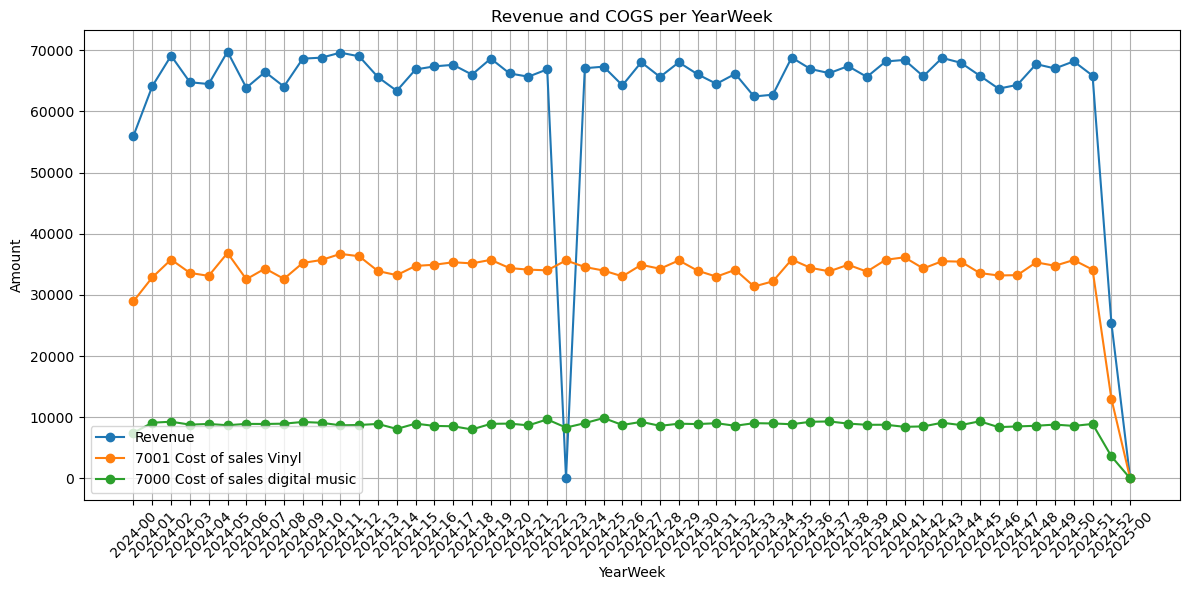

In [55]:
# Plot revenue and the COGS accounts per YearWeek
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(glg['YearWeek'], glg['Revenue'], label='Revenue', marker='o')
plt.plot(glg['YearWeek'], glg['7001 Cost of sales Vinyl'], label='7001 Cost of sales Vinyl', marker='o')
plt.plot(glg['YearWeek'], glg['7000 Cost of sales digital music'], label='7000 Cost of sales digital music', marker='o')
plt.title('Revenue and COGS per YearWeek')
plt.xlabel('YearWeek')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [57]:
# Train regression model on gl_data_grouped

#A2a)
X_features_list = ['5520 IT Hosting',
 '7000 Cost of sales digital music',
 '7001 Cost of sales Vinyl',
 '5510 Purchases']
X = glg[X_features_list]  

#A2b)
y = glg['Revenue'] 

#A3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

#A4a)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm

#A4b)
X_test = sm.add_constant(X_test)
X_train = sm.add_constant(X_train)

#A4c)
multivar_linreg = sm.OLS(y_train, X_train).fit()
print(multivar_linreg.summary())

#A4d)
y_pred_test = multivar_linreg.predict(X_test)
y_pred_train = multivar_linreg.predict(X_train)

#A4e)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

rmse_train = mse_train**0.5
rmse_test = mse_test**0.5

mape_train = ((y_train - y_pred_train) / y_train).abs().mean() * 100
mape_test = ((y_test - y_pred_test) / y_test).abs().mean() * 100

#A4f)
print("Mean Squared Error train:", mse_train, "test:", mse_test)
print("Mean Absolute Error train:", mae_train, "test:", mae_test)
print("Root Mean Squared Error train:", rmse_train, "test", rmse_test)
print("Mean Absolute Percentage Error train:", mape_train, "test:", mape_test)

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     13.65
Date:                Fri, 27 Jun 2025   Prob (F-statistic):           5.44e-07
Time:                        15:09:09   Log-Likelihood:                -455.99
No. Observations:                  43   AIC:                             922.0
Df Residuals:                      38   BIC:                             930.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

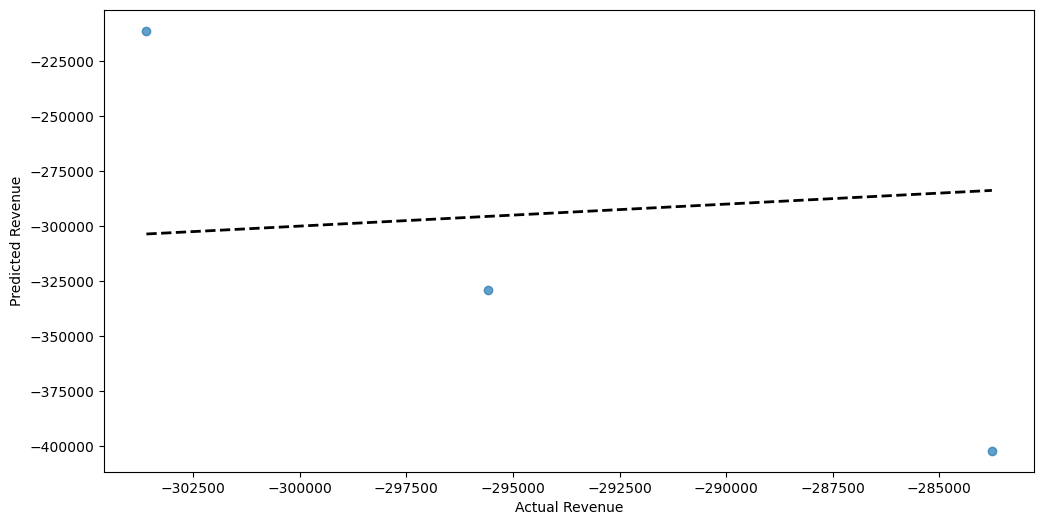

In [40]:
# Plot the results
import matplotlib.pyplot as plt

# Plot the actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.show()

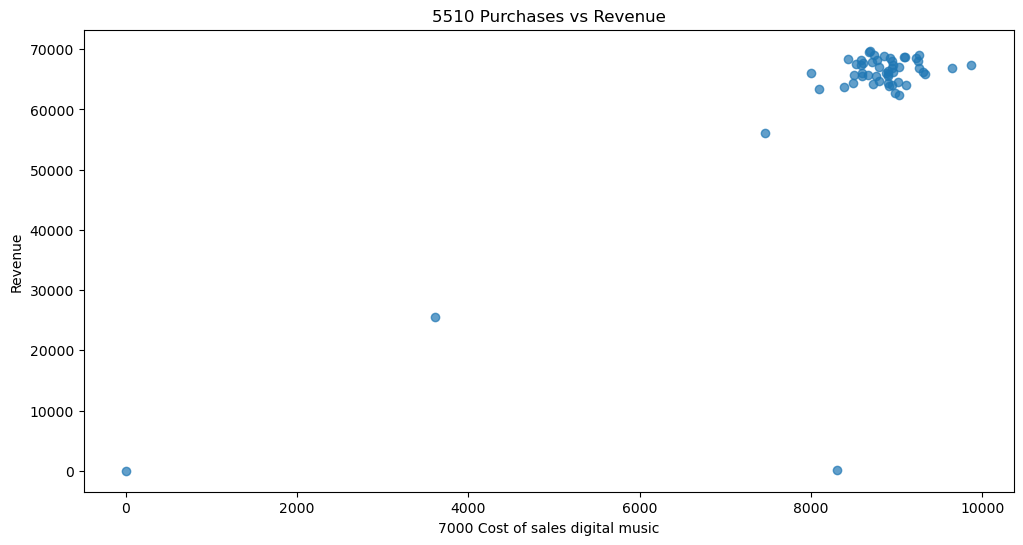

In [58]:
# Plot 7000 Cost of sales digital music vs Revenue
plt.figure(figsize=(12, 6))
plt.scatter(glg['7000 Cost of sales digital music'], glg['Revenue'], alpha=0.7)
plt.xlabel("7000 Cost of sales digital music")
plt.ylabel("Revenue")
plt.title("5510 Purchases vs Revenue")
plt.show()

In [ ]:
glg[glg['Revenue'] > -60000]

Account,YearWeek,1101 Bank account *313,1200 Inventory Vinyl,1300 Debtors,1500 VAT Payable,1520 VAT Recoverable,1600 Creditors,1670 Net wages,1780 Payable reservation for vacation allowance,1910 Accruals Payable,...,5511 Rent Expense,5512 Accounting and Audit Fees,5513 Utilities,5514 Car Lease,5520 IT Hosting,7000 Cost of sales digital music,7001 Cost of sales Vinyl,8000 Revenue digital music,8001 Revenue Vinyl,Revenue
0,2024-00,8927.58,-28961.27,24541.08,-11761.42,5503.02,2598.80,-22236.0,-2400.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7456.35,28961.27,-11405.74,-44608.21,-56013.95
52,2024-52,23952.74,-13039.77,-2599.54,-5344.11,585.27,6070.47,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3608.07,13039.77,-5589.20,-19862.59,-25451.79
53,2025-00,20445.14,0.00,-20445.14,0.00,0.00,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00


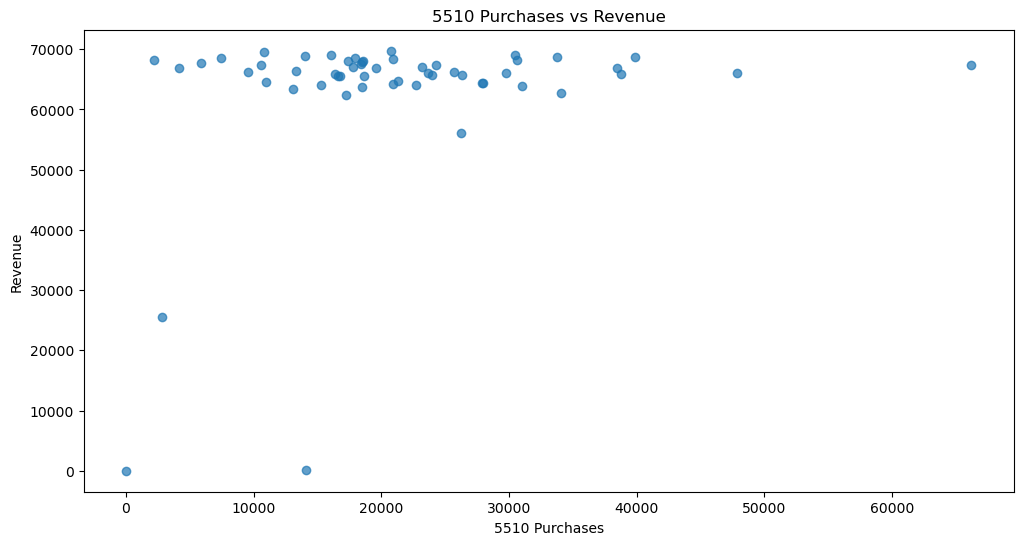

In [59]:
# Plot 5510 Purchases vs Revenue -> There seems to be no relationship (as the Model also told us)
plt.figure(figsize=(12, 6))
plt.scatter(glg['5510 Purchases'], glg['Revenue'], alpha=0.7)
plt.xlabel("5510 Purchases")
plt.ylabel("Revenue")
plt.title("5510 Purchases vs Revenue")
plt.show()

In [ ]:
# 5510 Seems to be an Opex account
gl_data[gl_data['Account'] == '5510 Purchases']

,Date,Period,Description,JournalCode,JournalDesc,JournalType,Booknr,AccountCode,AccountDesc,AccountType,Debit/Credit,Amount,Product ID,User,Relation_id,Relation_name,Source_id,Account,AmountNet,YearWeek
715,2024-09-25,2024-09,Purchase invoice from Tyco International,PJ,Purchases Journal,Purchases,PJ000364,5510,Purchases,Expense,Debit,5556.37,NaN,lotte_vanbeek,SUPL000005,Tyco International,NaN,5510 Purchases,5556.37,2024-38
910,2024-02-12,2024-02,Purchase invoice from Shell,PJ,Purchases Journal,Purchases,PJ000666,5510,Purchases,Expense,Debit,5871.23,NaN,yusuf_dirik,SUPL000040,Shell,NaN,5510 Purchases,5871.23,2024-06
1814,2024-10-21,2024-10,Purchase invoice from WorldCom,PJ,Purchases Journal,Purchases,PJ000229,5510,Purchases,Expense,Debit,2038.77,NaN,jeroen_kuyper,SUPL000028,WorldCom,NaN,5510 Purchases,2038.77,2024-42
2503,2024-01-30,2024-01,Purchase invoice from PostNL,PJ,Purchases Journal,Purchases,PJ000062,5510,Purchases,Expense,Debit,1538.14,NaN,ali_karimi,SUPL000029,PostNL,NaN,5510 Purchases,1538.14,2024-04
2887,2024-11-11,2024-11,Purchase invoice from Slack,PJ,Purchases Journal,Purchases,PJ000486,5510,Purchases,Expense,Debit,513.48,NaN,samira_achahbar,SUPL000051,Slack,NaN,5510 Purchases,513.48,2024-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637447,2024-09-09,2024-09,Purchase invoice from Intercom,PJ,Purchases Journal,Purchases,PJ000408,5510,Purchases,Expense,Debit,3019.23,NaN,ali_karimi,SUPL000032,Intercom,NaN,5510 Purchases,3019.23,2024-36
637564,2024-07-29,2024-07,Purchase invoice from T-Mobile,PJ,Purchases Journal,Purchases,PJ000541,5510,Purchases,Expense,Debit,8447.30,NaN,samira_achahbar,SUPL000084,T-Mobile,NaN,5510 Purchases,8447.30,2024-30
638916,2024-06-05,2024-06,Purchase invoice from Gall & Gall,PJ,Purchases Journal,Purchases,PJ000094,5510,Purchases,Expense,Debit,1119.00,NaN,jeroen_kuyper,SUPL000060,Gall & Gall,NaN,5510 Purchases,1119.00,2024-22
640475,2024-03-27,2024-03,Purchase invoice from Square,PJ,Purchases Journal,Purchases,PJ000442,5510,Purchases,Expense,Debit,3965.69,NaN,hafsa_bouali,SUPL000007,Square,NaN,5510 Purchases,3965.69,2024-12


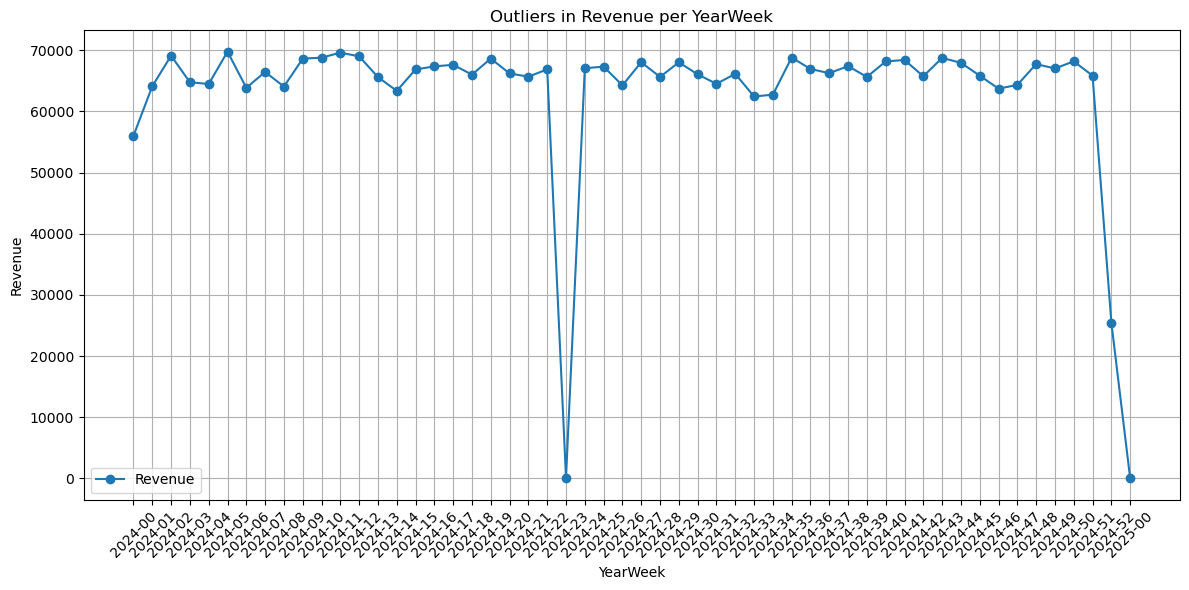

In [60]:
# Plot outliers in Revenue

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(glg['YearWeek'], glg['Revenue'], label='Revenue', marker='o')
plt.title('Outliers in Revenue per YearWeek')
plt.xlabel('YearWeek')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()